<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula04b_Classifica%C3%A7%C3%A3o%20multiclasse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)
X_reduced = X[:, [6, 9]]
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y,
                                                    test_size=0.2,
                                                    random_state=42)


In [30]:
from collections import Counter

print(Counter(y))
print(Counter(y_train))
print(Counter(y_test))

Counter({np.int64(1): 71, np.int64(0): 59, np.int64(2): 48})
Counter({np.int64(1): 57, np.int64(0): 45, np.int64(2): 40})
Counter({np.int64(0): 14, np.int64(1): 14, np.int64(2): 8})


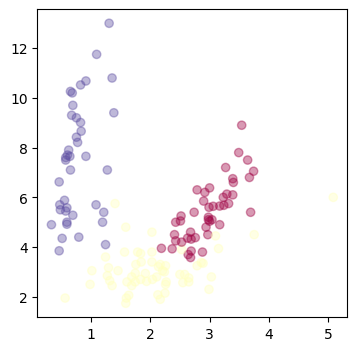

In [38]:
from matplotlib import pyplot as plt

def plot_dataset(X, y):
  plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.4, cmap='Spectral')

plt.figure(figsize=(4,4))
plot_dataset(X_train, y_train)
plt.show()

In [42]:
import numpy as np

y_hot = np.zeros((X_train.shape[0], len(set(y_train))), dtype=int)
for i, label in enumerate(sorted(list(set(y_train)))):
  idxs = np.where(y_train == label)[0]
  y_hot[idxs, i] = 1
y_hot[:10,:]

array([[0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0]])

In [45]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

def one_hot_encode(y, labels):
  y_hot = np.zeros((y.shape[0], len(labels)), dtype=int)
  for i, label in enumerate(labels):
    idxs = np.where(y == label)[0]
    y_hot[idxs, i] = 1
  return y_hot

class LinearClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    X = include_bias(X)
    self.labels = sorted(list(set(y)))
    y = one_hot_encode(y, self.labels)
    self.w = np.linalg.pinv(X) @ y
    return self

  def predict(self, X):
    X = include_bias(X)
    logits = X @ self.w
    idxs = np.argmax(logits, axis=1)
    y_pred = [self.labels[i] for i in idxs]
    return np.array(y_pred, dtype=int)

model = LinearClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Weights:\n {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights:
 [[-0.61104821  1.22996937  0.38107884]
 [ 0.33360723 -0.03878215 -0.29482508]
 [ 0.05141373 -0.14847237  0.09705864]]
Test accuracy: 0.8611111111111112


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)
model = LinearClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Weights:\n {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights:
 [[-2.10608847e+00  2.91935223e+00  1.86736235e-01]
 [ 1.27680573e-01 -1.46081625e-01  1.84010524e-02]
 [ 1.14831096e-02 -6.63166526e-02  5.48335430e-02]
 [ 3.46721659e-01 -4.88470715e-01  1.41749056e-01]
 [-3.91551213e-02  3.42819814e-02  4.87313986e-03]
 [-1.40507194e-04  2.43275282e-04 -1.02768088e-04]
 [-7.21191936e-02 -7.97377457e-03  8.00929681e-02]
 [ 1.37803511e-01  7.77650062e-02 -2.15568517e-01]
 [ 1.90672455e-02  2.82066313e-01 -3.01133558e-01]
 [-5.06139119e-02  8.36317686e-02 -3.30178568e-02]
 [-1.05557093e-02 -5.57119775e-02  6.62676868e-02]
 [-6.86255244e-02  2.28595977e-01 -1.59970452e-01]
 [ 1.25115818e-01  3.13108641e-02 -1.56426683e-01]
 [ 6.18820785e-04 -5.40374427e-04 -7.84463579e-05]]
Test accuracy: 1.0
